# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, DEVICE, PROJ_ROOT, BATCH_SIZE_TRANSFORMER
from script.trainer import Trainer, EarlyStopping
from models.ViT import ViTRegressor
import torch
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
from collections import defaultdict

2025-08-06 16:13:22.254 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/ViTRegressor-base_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.040381,2025-08-04 05:06:26.438566,2025-08-04 05:39:39.852541,0 days 00:33:13.413975,0.000003,0.5,0.003311,256,NaN,1,0.000520,0.040002,NaN,COMPLETE
1,1,0.004854,2025-08-04 05:39:45.146381,2025-08-04 06:13:33.362378,0 days 00:33:48.215997,0.000010,0.0,0.009204,512,NaN,1,0.000138,0.006143,0.005830,COMPLETE
4,4,0.004040,2025-08-04 06:25:33.560152,2025-08-04 06:59:25.918537,0 days 00:33:52.358385,0.000001,0.0,0.000003,128,128.0,2,0.008285,0.004138,0.004064,COMPLETE
11,11,0.002669,2025-08-04 07:59:07.836044,2025-08-04 08:32:47.391689,0 days 00:33:39.555645,0.000060,0.0,0.000454,512,NaN,1,0.000172,0.002706,NaN,COMPLETE
12,12,0.003324,2025-08-04 08:32:55.070641,2025-08-04 09:06:38.386634,0 days 00:33:43.315993,0.000001,0.0,0.000010,128,128.0,2,0.012699,0.003696,NaN,COMPLETE
15,15,0.003854,2025-08-04 09:34:15.245155,2025-08-04 10:08:11.566085,0 days 00:33:56.320930,0.000013,0.0,0.000192,512,2048.0,2,0.001055,0.003339,0.003862,COMPLETE
17,17,0.003667,2025-08-04 10:14:25.033721,2025-08-04 10:48:24.325875,0 days 00:33:59.292154,0.000001,0.0,0.000019,2048,128.0,2,0.337740,0.003301,NaN,COMPLETE
21,21,0.002885,2025-08-04 11:14:31.457743,2025-08-04 11:48:33.223666,0 days 00:34:01.765923,0.000002,0.0,0.000047,256,128.0,2,0.016650,0.003882,0.003112,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 5.950771116725249e-05, 'head_LR': 0.0004540989543256841, 'weight_decay': 0.00017241325439617218, 'head_layer_1': 512, 'num_layers': 1, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [7]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='regression', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='regression')
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='regression')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_TRANSFORMER, num_workers=8)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_TRANSFORMER, num_workers=8)

In [8]:
head_cfg = {
    'hidden_dims' : [512],
    'dropout_rate': params['dropout']
}
model = ViTRegressor(img_size=224, head_cfg=head_cfg, variant='base')
assert model.variant == 'base'

loss = torch.nn.MSELoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 15

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=BATCH_SIZE_TRANSFORMER, 
    task="regression", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/361 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 14/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.0056
5-fold CV loss: 0.0063
k-Fold CV loss: 0.00635


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'regression', epochs=EPOCHS, early_stopping=ES)


Epoch 1/15:   0%|          | 0/451 [00:00<?, ?it/s]

[1/15] Train Loss: 0.0068


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[1/15] Val Loss: 0.0046 



Epoch 2/15:   0%|          | 0/451 [00:00<?, ?it/s]

...

[6/15] Val Loss: 0.0050 



Epoch 7/15:   0%|          | 0/451 [00:00<?, ?it/s]

[7/15] Train Loss: 0.0010


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[7/15] Val Loss: 0.0045 
Stopping training due to EarlyStopping


/home/aislab/princisgh_map_completeness/map_completeness_estimation/src/script/visualization.py:26: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



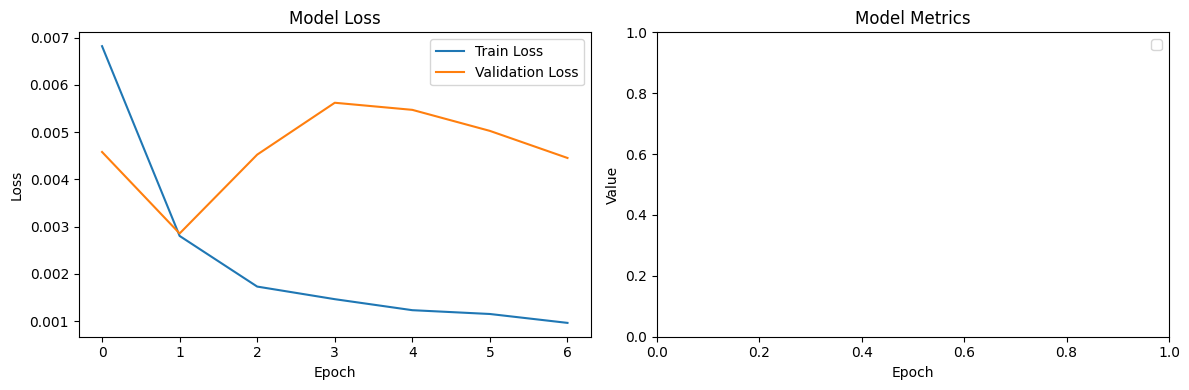

In [11]:
plot_history(trainer.history)

#### Validation Results

In [12]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR, 'ViTRegressor-base.pt')

Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

Model ViTRegressor-base.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [13]:
import torch.nn as nn

y_hat, y_true, loss = trainer.predict(test_loader)
y_hat, y_true = y_hat.squeeze(), y_true.squeeze()

# map filenames are expected in the format 'id@run@time'
env_id = lambda x: x.split('@')[0]
result_dict = defaultdict(list)
for i in range(len(test_ds)):
    mapname = test_ds.df['id'].iloc[i] 
    result_dict[env_id(mapname)].append(abs(y_hat[i] - y_true[i])) # store the absolute prediction error, grouped by map

average_errors = [(id, sum(lst) / len(lst)) for id, lst in result_dict.items()]

Evaluation:   0%|          | 0/95 [00:00<?, ?it/s]

W0806 17:34:46.772000 350530 torch/_dynamo/convert_frame.py:964] [16/8] torch._dynamo hit config.recompile_limit (8)
W0806 17:34:46.772000 350530 torch/_dynamo/convert_frame.py:964] [16/8]    function: 'torch_dynamo_resume_in_make_flat_list_of_images_at_244' (/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/transformers/image_utils.py:244)
W0806 17:34:46.772000 350530 torch/_dynamo/convert_frame.py:964] [16/8]    last reason: 16/2: len(images) == 32                                      
W0806 17:34:46.772000 350530 torch/_dynamo/convert_frame.py:964] [16/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0806 17:34:46.772000 350530 torch/_dynamo/convert_frame.py:964] [16/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
W0806 17:34:46.775000 350530 torch/_dynamo/convert_frame.py:964] [22/8] torch._dynamo hit config.recompile_limit (8)
W0806 17:34:46.775000 350

In [14]:
print("Map completeness percentage prediction results")
for env, err in average_errors:
    print(f"{env:>40} -> {float(err)*100:.2f}%")
print(f"\nAverage: {sum([x[1] for x in average_errors]) / len(average_errors)*100:.2f}%")

Map completeness percentage prediction results
                                     8-1 -> 3.15%
                                   E18-1 -> 6.07%
                                   E60-1 -> 3.16%
                      MediaCache_updated -> 2.53%
                          Rustic_updated -> 2.00%
                       Vipiteno2_updated -> 6.51%
                                    W8-1 -> 3.48%
         ZELLENBOROS_GRUPPENZONE_updated -> 4.16%
                       autoSales_updated -> 1.60%
                                   lab_a -> 6.66%
                                   lab_f -> 6.05%
      modern-office-floor-plan-1_updated -> 2.80%
                                office_b -> 3.29%
 scuola_secondaria_i_grado_mera__updated -> 1.53%
         south_mountain_school_1_updated -> 4.24%

Average: 3.82%
